# <span style="color:rgb(160,0,86)">Zeitreihenanalyse</span>

***

## <span style="color:rgb(160,0,86)">Lernziele</span>

- Sie wissen was eine Zeitreihe ist.
- Für einfache Zeitreihen können Sie eine **Trendlinie** und eine **Saisonfigur** bestimmen.  
- Sie können Zeitreihen mit **gleitenden Mittelwerten** oder **exponentiell** glätten.  

***

### <span style="color:rgb(160,0,86)">Was ist eine Zeitreihe?</span>

Eine **Zeitreihe** ist eine Folge von **zeitlich hintereinander** erhobenen Beobachtungswerten eines Merkmals bei einer statisischen Einheit. Oft haben die Zeitwerte regelmässige Abstände.     

#### <span style="color:rgb(160,0,86)">Typische Beispiele:</span>

- Tägliche Schlusskurse eines börsengehandelten Wertpapiers.
- Die monatlich festgestellt Arbeitslosenzahl in der Schweiz.
- Die Quartalsumsätze eines Unternehmens.
- Die jährliche Fördermenge einer Erdölraffinerie.
- Aktionen auf einem Computersystem in einer Logdatei
- Sensorwerte einer Traffic-Messungen. 

***

In der **Zeitreihenanalyse** werden Zeireihen auf Gesetzmässigkeiten untersucht, die sich aus der zeitlichen Abfolge der Beobachtungen ergeben. 

Die einfachsten Verfahren zielen darauf ab, den Zeitreihenverlauf auf systematische Komponenten wie **Trend** und **Saisoneinflüsse** zurückzuführen. Neben diesen systematischen Komponenten wird noch eine Restkomponente berücksichtigt, in der alle nicht systematischen **zufälligen** Einflüsse auf die Zeitreihe zusammengefasst werden.

Im **additiven Modell der Zeitreihe** wird also eine Schätzung wie folgt gemacht:
$$\pmb{\hat{y}(t)}\;=\;\textbf{glatte Komponente }\, \pmb{g(t)}\; + \;\textbf{zyklische Komponente }\, \pmb{s(t)}$$

### <span style="color:rgb(160,0,86)">Eine Zeitreihe zur Kohlendioxidkonzentration in der Atmosphäre.</span>

Die Messstation Mauna Loa ist eine meteorologische Forschungsstation in 3397 Metern Höhe auf dem Vulkan Mauna Loa auf Hawaii (https://gml.noaa.gov/ccgg/trends/data.html).

<p style="text-align: center"><img src="Bilder/MaunaLoa.png"></p>

Seit 1958 werden dort kontinuierlich $\mathsf{CO}_2$-Messungen durchgeführt, was das **Global Monitorin Laboratory** zu den längsten kontinuierlichen Zeitreihen der Welt macht:

In [3]:
#Mauna Loa CO2-Aufzeichnungen
import numpy as np
import pandas as pd
CO2 = pd.read_csv("/Users/muellefa/repos/ASTAT/SW13/Daten/co2_mm_mlo.csv", comment="#")

CO2.head(12)

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
5,1958,8,1958.6219,314.93,316.21,-1,-9.99,-0.99
6,1958,9,1958.7068,313.21,316.11,-1,-9.99,-0.99
7,1958,10,1958.7890,312.42,315.41,-1,-9.99,-0.99
8,1958,11,1958.8740,313.33,315.21,-1,-9.99,-0.99
9,1958,12,1958.9562,314.67,315.43,-1,-9.99,-0.99


In [4]:
df = CO2[["year","month","decimal date","average"]][CO2["year"]>=1990]
df.head()

,year,month,decimal date,average
382,1990,1,1990.0417,353.86
383,1990,2,1990.1250,355.10
384,1990,3,1990.2083,355.75
385,1990,4,1990.2917,356.38
386,1990,5,1990.3750,357.38


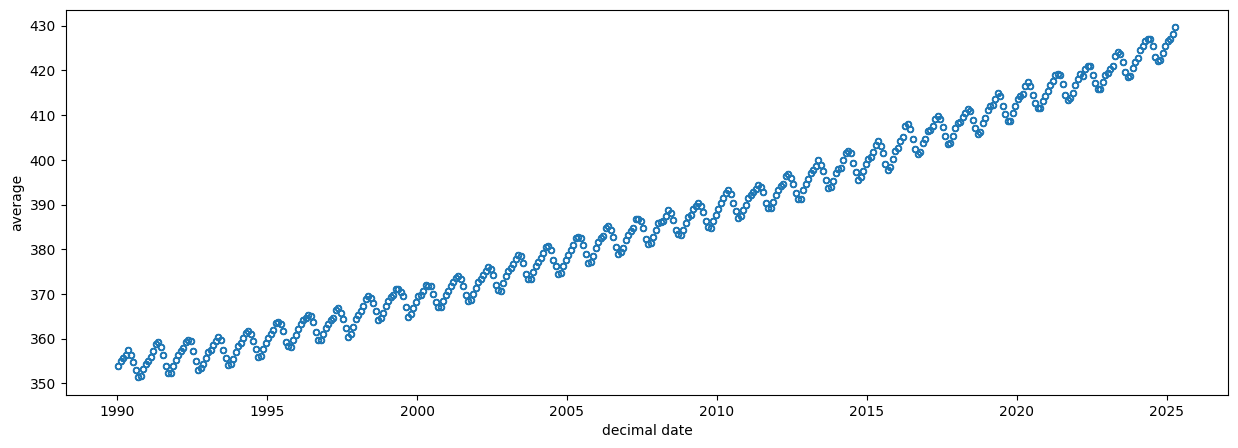

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15,5))
axi = fig.add_subplot(1,1,1)
df.plot.scatter(x = "decimal date", y = "average", ax = axi, marker="$\u25EF$")

plt.show()

In [6]:
from scipy.optimize import minimize 

def model_linear(time,a=1,b=0):
    # CO2-Konzentration = a * Zeit + b (linear)
    return a*time + b

def model_potenz(time,a=1,r=1,b=0):
    # CO2-Konzentration = a * Zeit^r  + b (potenz)
    return a*(time**r) + b

# Zeitverschiebung => kleiner Werte
t = df["decimal date"] - 1989

# coeffs = [a,b]
def RSS_linear(coeffs):
    residuen = df["average"] - model_linear(t,a=coeffs[0],
                                              b=coeffs[1])
    return (residuen**2).sum()

# coeffs = [a,r,b]
def RSS_potenz(coeffs):
    residuen = df["average"] - model_potenz(t,a=coeffs[0],
                                              r=coeffs[1],
                                              b=coeffs[2])
    return (residuen**2).sum()    

fit_linear = minimize(RSS_linear,x0=[0,0],method = 'powell')
print(fit_linear.success)

fit_potenz = minimize(RSS_potenz,x0=[1,1,300],method = 'powell')
print(fit_potenz.success)

True
True


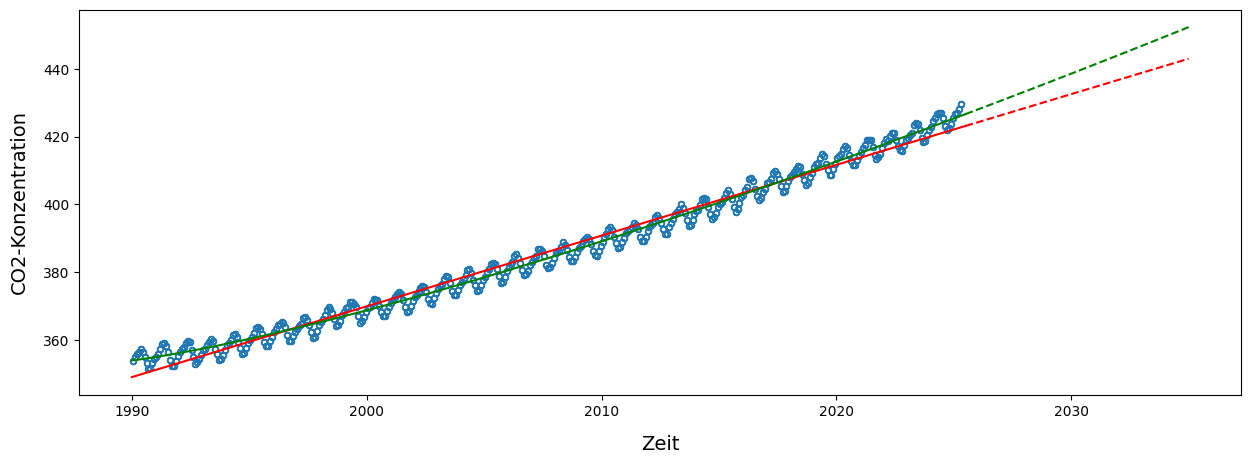

In [7]:
def predict_linear(x):
    return model_linear(x - 1989,a=fit_linear.x[0],
                                 b=fit_linear.x[1])

def predict_potenz(x):
    return model_potenz(x - 1989,a=fit_potenz.x[0],
                                 r=fit_potenz.x[1],
                                 b=fit_potenz.x[2])

fig = plt.figure(figsize=(15,5))
axi = fig.add_subplot(1,1,1)
df.plot.scatter(x = "decimal date", y = "average", ax = axi, marker="$\u25EF$")

x = np.linspace(1990,2025.5,100)
x_pred = np.linspace(2025.5,2035,100)
y_lin = predict_linear(x) 
y_pot = predict_potenz(x) 
y_lin_pred = predict_linear(x_pred) 
y_pot_pred = predict_potenz(x_pred) 
axi.plot(x,y_lin,color="red",lw=1.5)
axi.plot(x_pred,y_lin_pred,color="red",lw=1.5,linestyle='dashed')
axi.plot(x,y_pot,color="green",lw=1.5)
axi.plot(x_pred,y_pot_pred,color="green",lw=1.5,linestyle='dashed')
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)


plt.show()

In [8]:
df["residum"] = df["average"] - predict_potenz(df["decimal date"])
df.head(12)

,year,month,decimal date,average,residum
382,1990,1,1990.0417,353.86,-0.105613
383,1990,2,1990.1250,355.10,1.057848
384,1990,3,1990.2083,355.75,1.629608
385,1990,4,1990.2917,356.38,2.179655
386,1990,5,1990.3750,357.38,3.098255
387,1990,6,1990.4583,356.39,2.025379
388,1990,7,1990.5417,354.89,0.440985
389,1990,8,1990.6250,353.06,-1.474670
390,1990,9,1990.7083,351.38,-3.241638
391,1990,10,1990.7917,351.69,-3.019978


In [9]:
means = [df["residum"][df["month"]==i].mean() for i in range(1,13)]

mean_seasonal = ((df.shape[0]//12+1)*means)[0:df.shape[0]]

df["mean_seasonal"] = np.array(mean_seasonal)
df.head(20)

,year,month,decimal date,average,residum,mean_seasonal
382,1990,1,1990.0417,353.86,-0.105613,0.208098
383,1990,2,1990.1250,355.10,1.057848,0.871601
384,1990,3,1990.2083,355.75,1.629608,1.531977
385,1990,4,1990.2917,356.38,2.179655,2.712081
386,1990,5,1990.3750,357.38,3.098255,3.112927
387,1990,6,1990.4583,356.39,2.025379,2.343320
388,1990,7,1990.5417,354.89,0.440985,0.481456
389,1990,8,1990.6250,353.06,-1.474670,-1.761680
390,1990,9,1990.7083,351.38,-3.241638,-3.392288
391,1990,10,1990.7917,351.69,-3.019978,-3.356572


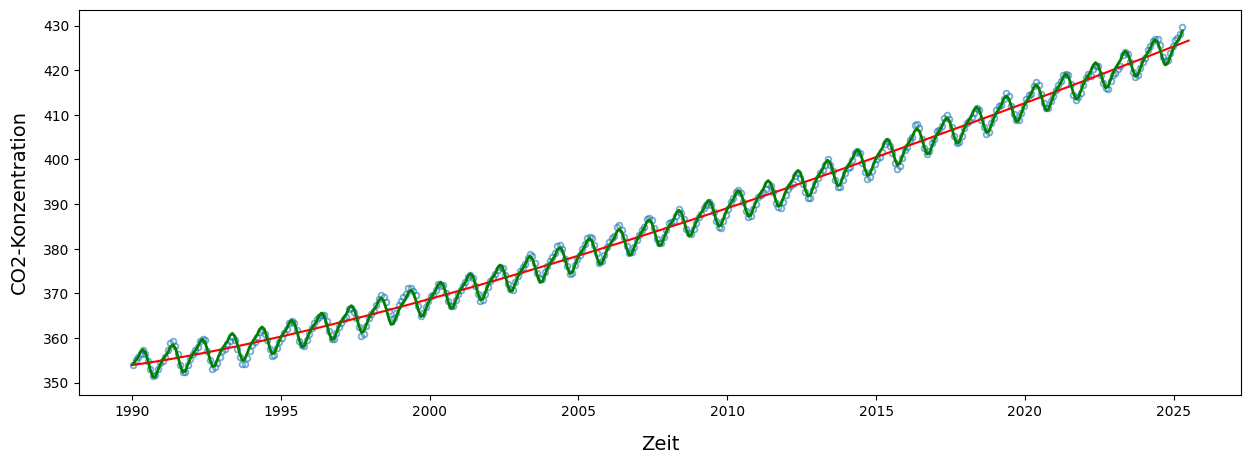

In [10]:
fig = plt.figure(figsize=(15,5))

axi = fig.add_subplot(1,1,1)

df.plot.scatter(x = "decimal date", y = "average", 
                ax = axi, marker="$\u25EF$",alpha=0.5)

x = np.linspace(1990,2025.5,100)
y = predict_potenz(x) 

axi.plot(x,y,color="red",lw=1.5)

x_fit = df["decimal date"]
y_fit = predict_potenz(x_fit)+np.array(mean_seasonal) 
axi.plot(x_fit,y_fit,color="green",lw=2)
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)


plt.show()

In [11]:
R_squared_trend = predict_potenz(df["decimal date"]).var() / df["average"].var()

R_squared = (predict_potenz(df["decimal date"])+
             np.array(mean_seasonal)   ).var() / df["average"].var()

print(R_squared_trend,R_squared)

0.989539328775981 0.998306409486052


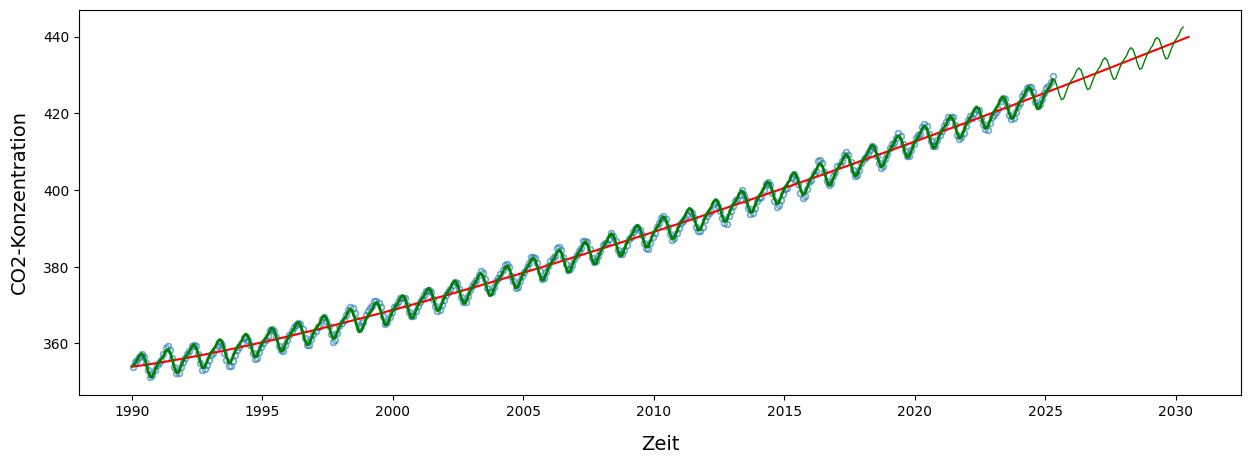

In [12]:
fig = plt.figure(figsize=(15,5))
axi = fig.add_subplot(1,1,1)

df.plot.scatter(x = "decimal date", y = "average", ax = axi,
                marker="$\u25EF$",alpha=0.5)
x = np.linspace(1990,2030.5,100)
y = predict_potenz(x) 
axi.plot(x,y,color="red",lw=1.5)
x_fit = df["decimal date"]
y_fit = predict_potenz(x_fit)+np.array(mean_seasonal) 
axi.plot(x_fit,y_fit,color="green",lw=2)
x_pred = np.array(x_fit.iloc[df.shape[0]-5*12:df.shape[0]])+5
y_pred = predict_potenz(x_pred)+np.array(mean_seasonal)[5:65]
axi.plot(x_pred,y_pred,color="green",lw=1)
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)


plt.show()

### <span style="color:rgb(160,0,86)">Was ist eine Glättung einer Zeitreihe?</span>

Eine einfache Methode der Glättung von historischen Zeitreihen besetzt darin, kurzefristige zufällige, saisonale oder auch konjunkturelle Schwankungen zu eliminieren, indem man die Zeitreihenwerte über mehrere, aufeinander folgende Perioden mit einem **gleitenden Durchschnitt** mittelt.
- Für eine **ungerade**  Periodenlänge $\pmb{L}$ ist der **gleitende zentrierte Durchschmitt**:
$$\pmb{\bar{y}_{(L)}(t)}\;=\;\pmb{\frac{1}{L}\;\underbrace{\left(y_{t-\frac{L-1}{2}}+\ldots+y_t+\ldots + y_{t+\frac{L-1}{2}}\right)}_{L\text{ Werte}}}$$
Also gilt zum Beispiel für $\pmb{L}=5$: $$\pmb{\bar{y}_{(5)}(\textcolor{blue}{t})}\;=\;\pmb{\frac{1}{5}\;\left(y_{t-2}+y_{t-1}+\textcolor{blue}{y_t}+ y_{t+1} + y_{t+2}\right)}$$ 
- Für eine **gerade**  Periodenlänge $\pmb{L}$ ist der **gleitende zentrierte Durchschmitt**:
$$\pmb{\bar{y}_{(L)}(t)}\;=\;\pmb{\frac{1}{L}\;\underbrace{\left(\textcolor{red}{\frac{1}{2}\cdot y_{t-\frac{L}{2}}}+y_{t-\frac{L}{2}+1}+\ldots + y_{t+\frac{L}{2}-1}+ \textcolor{red}{\frac{1}{2}\cdot  y_{t+\frac{L}{2}}}\right)}_{L+1\text{ Werte}}}$$
Also gilt zum Beispiel für $\pmb{L}=4$: $$\pmb{\bar{y}_{(4)}(\textcolor{blue}{t})}\;=\;\pmb{\frac{1}{4}\;\left(\frac{1}{2}\cdot y_{t-2}+y_{t-1}+\textcolor{blue}{y_t}+ y_{t+1} + \frac{1}{2}\cdot y_{t+2}\right)}$$

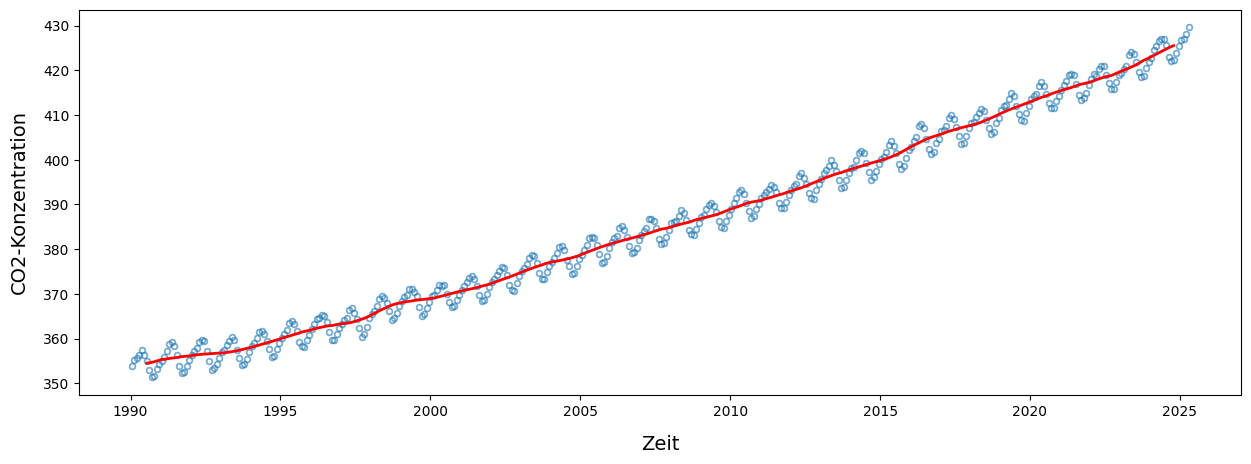

In [13]:
# Trendline mit Glättung -> ohne minimizer!
d = 12
smoothed_c = [1/d * (df["average"].iloc[i]/2 + 
                      df["average"].iloc[i+1:i+d].sum() + 
                      df["average"].iloc[i+d]/2) 
              for i in range(0,df.shape[0]-d)]

fig = plt.figure(figsize=(15,5))
axi = fig.add_subplot(1,1,1)

df.plot.scatter(x = "decimal date", y = "average", 
                ax = axi, marker="$\u25EF$",alpha=0.5)
x_trend = df["decimal date"][:df.shape[0]-d] + 0.5
y_trend = np.array(smoothed_c) 
axi.plot(x_trend,y_trend,color="red",lw=2)
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)

plt.show()

Beim gleitenden Durchschnitt werden alle Werte der Periode $\pmb{L}$ gleich stark gewichtet. Bei der **exponentiellen Glättung** werden die aktuellen Werte stärker gewichtet als ältere Beobachtungen, die exponentiell weniger Einfluss haben. Die geglätteten Werte können *rekursiv* berechnet werden: $$\pmb{\bar{y}(t)} \;=\; \pmb{\alpha\cdot y_t + (1-\alpha)\cdot\bar{y}(t-1)}$$

Der Parameter $\pmb{\alpha}$ heisst **Glättungsfaktor**. 
- Für $\pmb{\alpha}=1$ ist der Vorhersagewert gleich dem Messwert (keine Glättung)
- Für $\pmb{\alpha}=0$ ist der Vorhersagewert unverändert (Glättung zu einer Parallelen zur $x$-Achse)

In Abhängigkeit von $\,\pmb{\alpha}\,$ werden die Werte der Vergangenheit stärker oder schwächer berücksichtigt:

$$\begin{align*} \pmb{\bar{y}(1)} &= \pmb{\alpha\cdot \bar{y}(1) + (1-\alpha)\cdot\bar{y}(0)}\\
\pmb{\bar{y}(2)} &= \pmb{\alpha\cdot \bar{y}(2) + (1-\alpha)\cdot\bar{y}(1)}\rule{0cm}{1cm}\\ 
 &= \pmb{\alpha\cdot \bar{y}(2) + (1-\alpha)\cdot\left[\,\alpha\cdot \bar{y}(1) + (1-\alpha)\cdot\bar{y}(0)\right]}\,\rule{0cm}{1cm} \\ &= \pmb{\alpha\cdot \bar{y}(2) + \alpha(1-\alpha)\bar{y}(1) + (1-\alpha)^2\cdot\bar{y}(0)}\,\rule{0cm}{1cm} \\
 \pmb{\bar{y}(3)} &= \pmb{\alpha\cdot \bar{y}(3) + \alpha(1-\alpha)\bar{y}(2) + \alpha(1-\alpha)^2\cdot\bar{y}(1) + (1-\alpha)^3\cdot\bar{y}(0)}\,\rule{0cm}{1cm} \\
&\;\;\vdots \rule{0cm}{1cm}\\
\pmb{\bar{y}(t)} &= \pmb{\alpha\cdot \bar{y}(t) + \alpha(1-\alpha)\bar{y}(t-1) + \alpha(1-\alpha)^2\cdot\bar{y}(t-2) + \ldots + (1-\alpha)^t\cdot\bar{y}(0)}\,\rule{0cm}{0.8cm}\\
&\;\;\vdots\end{align*}$$

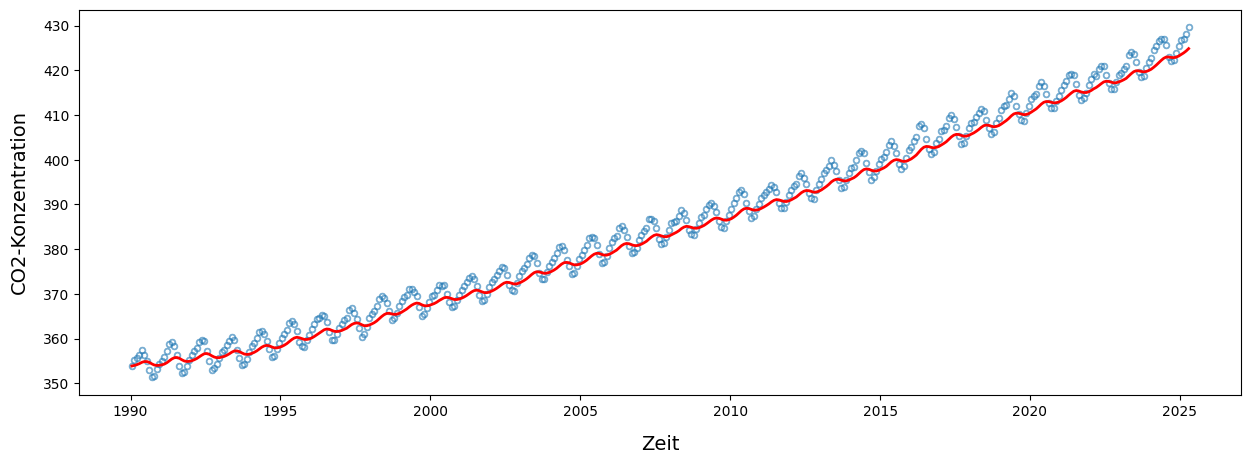

In [14]:
 # einfache exponentielle Glättung
y_smooth = [df["average"].iloc[0]]
alpha = 0.1
for i in range(1,df.shape[0]):
    y_smooth.append(alpha * df["average"].iloc[i] + (1-alpha)*y_smooth[-1])

fig = plt.figure(figsize=(15,5))
axi = fig.add_subplot(1,1,1)

df.plot.scatter(x = "decimal date", y = "average", ax = axi,
                marker="$\u25EF$",alpha=0.5)
x_trend = df["decimal date"]
y_trend = np.array(y_smooth) 
axi.plot(x_trend,y_trend,color="red",lw=2)
axi.set_xlabel("Zeit",size=14,labelpad=12)
axi.set_ylabel("CO2-Konzentration",size=14,labelpad=10)

plt.show()

### <span style="color:rgb(160,0,86)">Aufgabe 1</span>
Laden Sie die neusten $\mathsf{CO}_2$-Messungen vom **Global Monitorin Laboratory** herunter und vergleichen Sie die real gemessenen Werte mit unserer Prognose oben.

In [15]:
# To do!

### <span style="color:rgb(160,0,86)">Aufgabe 2</span>
Machen Sie eine **Zeitreihenanalyse** für die Anzahl Fluggäste pro Monat an Berliner Flughäfen (beobachtet von Januar 2011 bis Dezember 2017). Die Daten finden sie in der Datei *Fluggaeste.sav* im Ordner Daten.

In [16]:
# To do!

![HSLU](Bilder/LogoHSLU.png)